Read README.md first.

author: Xu Chen, 2021.08

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import numpy.fft as fft
import sys
sys.path.append('/data/inspur_disk01/userdir/ucas_students/xuc/FAST/G15/test_pipe/')
from util import *
from copy import deepcopy
from tqdm import tqdm

In [2]:
subname = '../data6/sub/M31_SnapShot_6_snapshot-M06_W-20210730-specs_T-bld.hdf5'
sub = h5py.File(subname,'r')

# example polar yy

以偏振yy的前2000条为例

In [3]:
data = get_data(sub,polar='yy')[:][:2000]
freq = sub['freq'][:]
is_on = sub['is_on'][:][:2000]

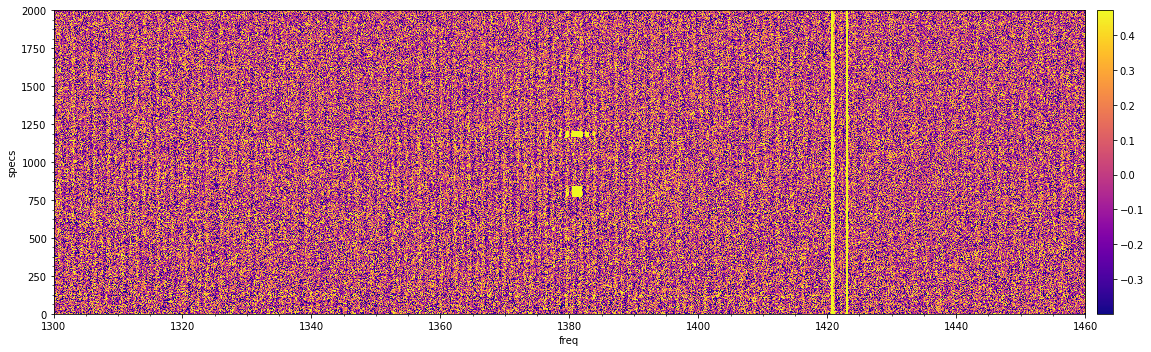

In [4]:
plot_waterfall(sub,data,per_vmin_max=.90,figsize=(18,5),cmap = 'plasma')

# time RFI


* --time_rfi：标记时域上突然出现的RFI，根据占据的频率长度，分为short-freq/long-freq。
    对该频率区间内的所有谱线做频率方向的平均后，画出一维的图。如果有`--lf`或`--sf`，可以省略`--time_rfi`

* --sf
* --sf_frange: 一个典型的1～2MHz宽时域RFI，经常出现在1380～1382MHz。
* --sf_file: 或者可以指定一个二维数组的npy文件路径，在里面循环找，例如以下是只找时域RFI:
    ```
    time_rfi_file = '/data/inspur_disk01/userdir/ucas_students/xuc/FAST/G15/newG15/time_rfi_list.npy'
    python cli_markRFI.py $subname --outdir ./data \
            --sf \
            --sf_file $time_rfi_file --sf_times 1.8 --sf_thr 0 --sf_rfi_last 20 --sf_T_thr_times 3 \
            --plot --ylim -1 5 --vmin_max -.05 .05 -f  || exit 1 

    INFO: Looking for short-freq time RFI in [1378 1384] ... [markRFI]
    Found :D
    INFO: Looking for short-freq time RFI in [1310 1315] ... [markRFI]
    Found :D
    INFO: Looking for short-freq time RFI in [1320 1325] ... [markRFI]
    Found :D
    Finish
    ```
* --sf_frange_step:如果sf_frange和sf_file不指定，将以这个step(MHz)在频率上循环，对每个区间找一次时域RFI
    ```
    python cli_markRFI.py $subname \
            --outdir $outdir \
            --mw_frange 1420.3 1423.3 --sf_frange_step 20 \
            --sf --sf_times 3 --sf_thr 0 --sf_rfi_last 10 --sf_T_thr_times 3 \
            --lf --lf_frange 1400 1450 --lf_times 1.5 --lf_thr 0 --lf_rfi_last 50 --lf_ext 10 \
            --plot --ylim -.5 .5 --vmin_max -.05 .05 -f  || exit 1 
    ```
* --sf_times: 大于各谱线之中，中值的10倍，初步认为异常
* --sf_thr: 边缘处与附近值的差是中值的倍数，找出时间方向的边缘处陡峭的
* --sf_rfi_last: 持续出现的谱线数
* --sf_T_thr_times: 选定区域后，大于温度阈值的被标记
* --sf_ext: 选定区域后，扩展边缘

* --lf
* --lf_beams: 已知出现大卫星干扰的波束，其他不搜寻。如果不设置就对所有波束搜寻。
* --lf_frange: 大范围频率
* --lf_times: 大于各谱线之中，中值1.5倍，初步认为异常.
* --lf_thr: 不需要边缘陡峭，所以设为0
* --lf_rfi_last: 持续出现的谱线数
* --lf_ext: 选定区域后，扩展边缘

* --save_tf: 将sf单独保存为```dict_out['short_rfi']```

输出文件名含tr

In [5]:
from markRFI import mask_time_rfi,real_rms
spec = deepcopy(data[0,:])
RMS = real_rms(spec,freq,sigma=6,rms_vrange=[1390,1400])

In [18]:
s_rfi = mask_time_rfi(data,freq,T_thr_times = 3, rtype = 'short-freq',frange =[1300,1320],times = 3,thr = 0,
                      ext_add=0,rfi_width_lim = 10,plot = True,RMS=RMS)

No short-freq time rfi is found.
Finish


INFO: Looking for short-freq time RFI in [1370, 1390] ... [markRFI]
Found :D
Finish


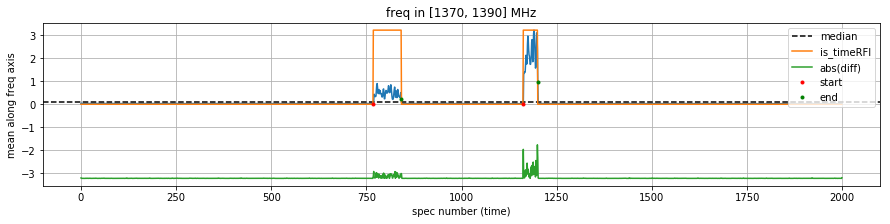

In [19]:
s_rfi = mask_time_rfi(data,freq,T_thr_times = 3, rtype = 'short-freq',frange =[1370,1390],times = 3,thr = 0,
                      ext_add=0,rfi_width_lim = 10,plot = True,RMS=RMS)

In [20]:
T = deepcopy(data)
T[s_rfi] = np.nan

确认T_thr_times是否能将RFI基本mask掉，太低会mask其他东西

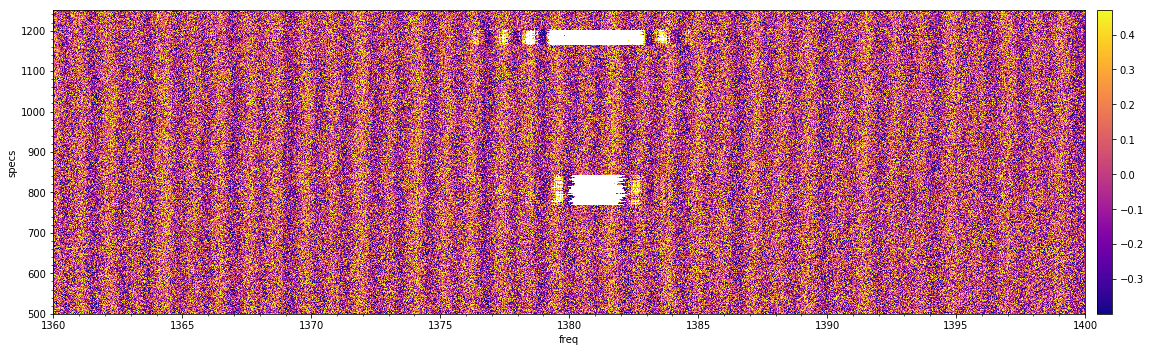

In [21]:
plot_waterfall(sub,T,per_vmin_max=.90,figsize=(18,5),cmap = 'plasma',xylim = (1360,1400,500,1250))

跑标记RFI程序
这里一并搜索了lf
```
python cli_markRFI.py $fname \
        --outdir $outdir \
        --mw_frange 1420.3 1423.3 --sf_frange_step 20 \
        --sf --sf_times 3 --sf_thr 0 --sf_rfi_last 10 --sf_T_thr_times 3 \
        --lf --lf_frange 1400 1450 --lf_times 1.5 --lf_thr 0 --lf_rfi_last 50 --lf_ext 10 \
        --plot --ylim -.5 .5 --vmin_max -.05 .05 -f  || exit 1 
```
加载rfi文件

In [22]:
rfiname = '../data6/rfi/M31_SnapShot_6_snapshot-M03_W-20210730-specs_T-bld-tr.hdf5'
rfi = h5py.File(rfiname,'r')
is_rfi = rfi['is_rfi'][:][:2000]

# MW range
有MW、M31的区域，下面会被替代为驻波

(1420.3, 1423.3)

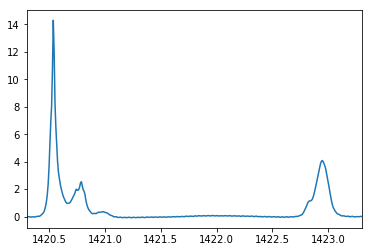

In [23]:
plt.plot(freq,np.mean(data,axis = 0))
plt.xlim(1420.3,1423.3)

In [24]:
mw_frange = (1420.3,1423.3)
from baseline_2 import *
mw_use = (freq > mw_frange[0])&(freq < mw_frange[1])

# Replace RFI or strong sources

* --rfi_method: 防止大rfi/强源干扰fft，提供7种方法：'subtract trpdr',
                      'subtract tr','subtract rfi', 'lower','set zeros','set noise','near ripple'
  推荐'near ripple'

* --rms_sigma: 如果区间有干扰，还是用该频率减去一个高斯平滑，得到准确的rms。此为高斯滤波的sigma。
* -rfi, --rfi_fname: 指定标记rfi的文件。无则自动到输入文件的上一级名为/rfi/的文件夹里找含-tr的文件，找不到则在当前路径找。

* --mw_frange: 银河系(或者M31，M33都)存在的区域

这里只介绍'near ripple'的参数

'near ripple'使用高流量处附近的驻波替代。例如
    ```
    fname = subnames[1]
    outdir = './data'
    sepname='/data/inspur_disk01/userdir/jyj/FAST/jingyj/M31_snapshot/data/M31_SnapShot_6_snapshot-M'
    python cli_baseline_fft.py $fname --outdir $outdir \
            -sep $sepname  --s_method_t boxcar --s_sigma_t 100 \
            --mw_frange 1420.3 1423.3 --rms_sigma 6 --rms_frange 1390 1400 \
            --rfi_method 'near ripple' --times_lower_thr 4 \
            --rfi_width_lim 15 --ext_sec 20 --ext_freq 1.3 \
            --fft_method rfft --chan_wide 10 --chan_narr 3 \
            --amp_thr_mean_factor 3 --amp_thr_factor 4 --choose_method 'interpolate' \
            --rip_base --rip_1mhz --rip_0_04mhz --fft_ylim -5 60 \
            --plot --ylim -1 .5 --vmin_max -.05 .05 -f --fill_rfi nan --keep_polar || exit 1 
    ```
    * 只需要已知时域rfi的文件，即*-tr*。    
      如果没有时域RFI，设置-rfi 'none'即可。
    * --times_lower_thr:大于RMS这么多倍的会被替代
    * --rfi_width_lim,--ext_sec: 以上处理的范围，宽度阈值和扩展通道数(同周期rfi里的含义)
    * --ext_freq: 扩展边缘(MHz)，再寻找强流量两边的最低点，先使用左/右边的一段代替强流量处
    
    * 输出文件名含fft_blde.

通过单条谱线尝试参数，划分被replace的范围

(-2, 2)

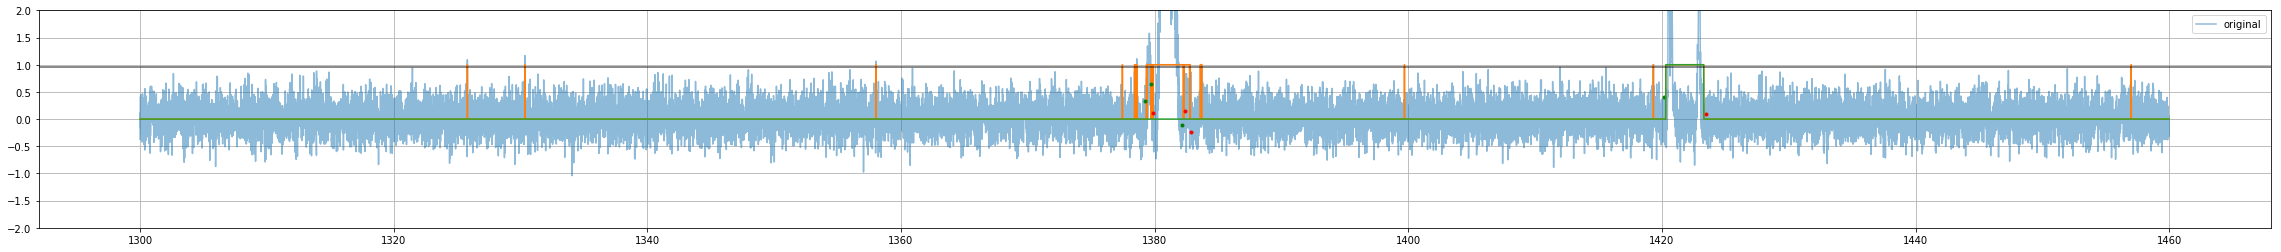

In [28]:
tn = 800
spec = data[tn,:]
from markRFI import real_rms,rms
RMS = real_rms(spec,freq,sigma=6,rms_vrange=[1390,1400])

thr_lower = RMS*4
low_use = (spec > thr_lower) | mw_use| is_rfi[tn]

from markRFI import get_startend
start,end = get_startend(low_use,rfi_width_lim=15, ext_sec=20)

fig = plt.figure(figsize=(40,4))
ax = fig.add_subplot(111)
ax.plot(freq,spec,label='original',alpha = .5)
ax.plot(freq,low_use)
ax.plot(freq[start],spec[start],'g.')
ax.plot(freq[end],spec[end],'r.')
ax.plot(freq,mw_use)
ax.axhline(thr_lower,c='k',alpha = .6)
ax.grid();ax.legend()

ax.set_ylim(-2,2)

## replace

In [30]:
rep_args = {}
rep_args['rms_sigma'] = 6
rep_args['rms_frange'] = [1390,1400]
rep_args['times_lower_thr'] = 4
rep_args['rfi_width_lim'] = 15
rep_args['ext_sec'] = 20
rep_args['ext_freq'] = 1.3

In [31]:
data_rep = replace_rfi(data,freq,is_rfi = is_rfi,time_rfi =is_rfi, method='near ripple',
                mw_use = mw_use, **rep_args)

INFO: Replace RFI with near ripple method ... [baseline_2]


100%|██████████| 2000/2000 [00:03<00:00, 599.95it/s]


瀑布图的分别比较

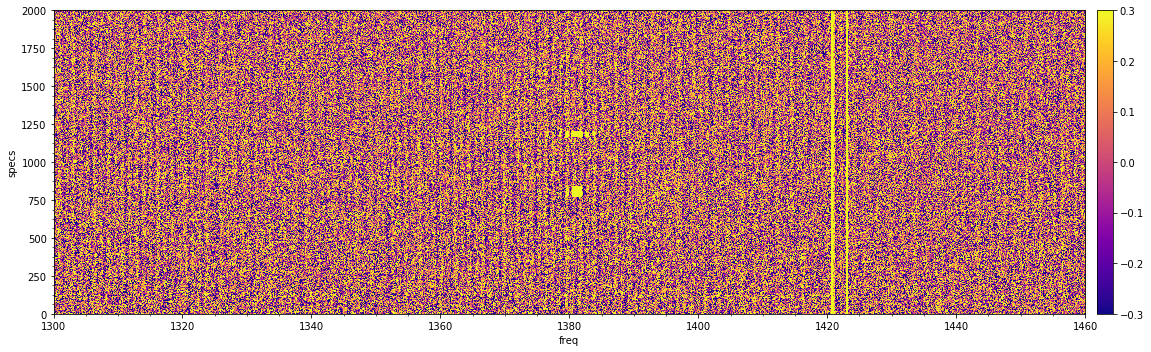

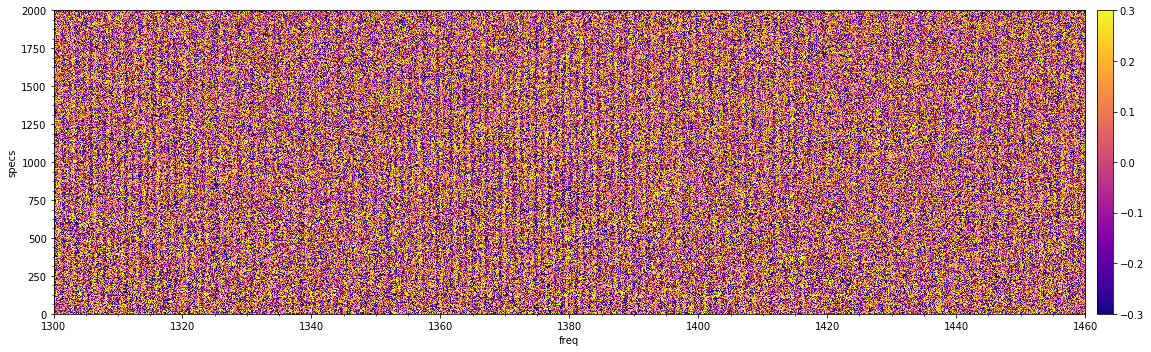

In [34]:
plot_waterfall(sub,data = data,vmin_max=[-.3,.3],cmap='plasma',figsize=(18,5))
plot_waterfall(sub,data = data_rep,vmin_max=[-.3,.3],cmap='plasma',figsize=(18,5))

# FFT remove 1MHz ripples

* --fft_method: 目前只提供rfft，mean的方法见‘cli_baseline_mean去基线‘

* --amp_thr_mean_factor: fourier空间的平均振幅大于阈值的模，会被识别为已知的几种驻波。这里输入的是中值的倍数
* --amp_thr_factor: fourier空间的每一谱线的振幅大于阈值，会被选中为驻波一部分被去除。这里输入的是中值的倍数
* --chan_wide: 距离驻波的模的中心左右各(2 * chann - 1)个通道数的模，作为驻波的一部分被选中，这里为由于fourier空间中峰比较宽，多选一些
  --chan_narr: 同理，窄一些的
* --choose_method: 选择fourier模的方法，'all'或者'interpolate'
  
* --rip_base: 去除基频(实空间的常数)
* --rip_1mhz: fft去除1.08mhz 驻波，单镜都有的
* --rip_2mhz: fft去除1.92mhz 驻波，只有M06 yy有
* --rip_0_04mhz: fft去除0.039mhz 驻波，很弱的偏振驻波，由于光纤反射

* --fft_ylim: 画fft模的上下限 

* --fill_rfi: 对输入的rfi区域，可以填nan或者保持原样。对应'nan','rfi'。需要注意只有输入对应RFI文件才能填nan。

In [36]:
fftf = FFT(data_rep, freq)
x = fftf.x
amp_data = fftf.amp
amp = np.mean(amp_data,axis=0)

(0, 3)

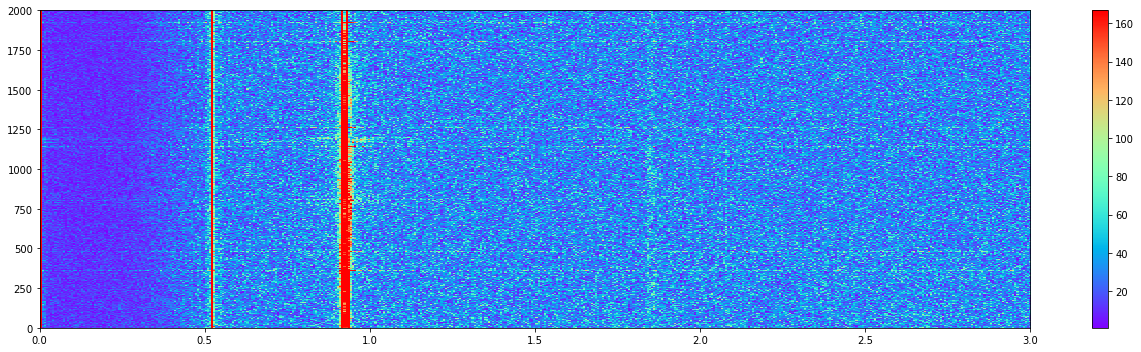

In [37]:
plt.figure(figsize=(18,5))
vmin,vmax = percent_vminmax(amp_data,percent = .999)
plt.imshow(amp_data,origin='lower',aspect='auto',extent=(x[0],x[-1],0,amp_data.shape[0]),
        vmin=vmin,vmax=vmax,cmap='rainbow')

plt.tight_layout()
plt.colorbar()
plt.xlim(0,3)

从平均的fourier模，可以看出明显的几种驻波，2mhz、1mhz、0.04mhz和0.92mhz周期RFI

Text(0.5, 0, 'k [$\\mu$s]')

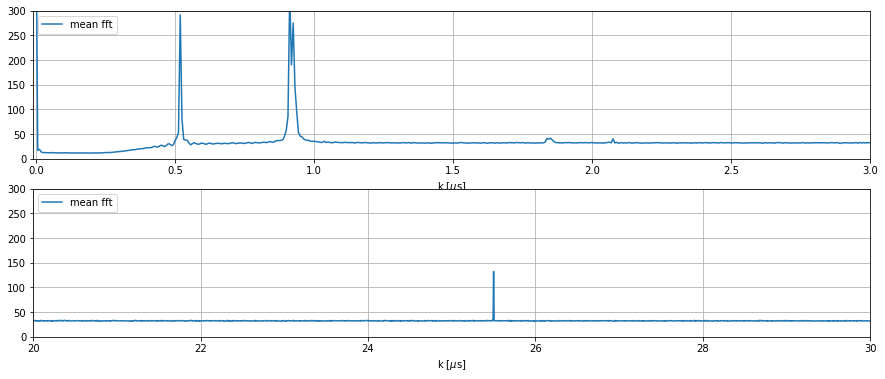

In [42]:
fig = plt.figure(figsize=(15,6))
ax = fig.add_subplot(211) 
ax.plot(x,amp, label = 'mean fft')
ax.set_xlim(-.01,3)
ax.set_ylim(0,300)
ax.grid();ax.legend(loc = 2)
ax.set_xlabel('k [$\mu$s]')

ax = fig.add_subplot(212) 
ax.plot(x,amp, label = 'mean fft')
ax.set_xlim(20,30)
ax.set_ylim(0,300)
ax.grid();ax.legend(loc = 2)
ax.set_xlabel('k [$\mu$s]')

In [35]:
fit_args = {}
fit_args['chan_wide'] = 5
fit_args['chan_narr'] = 3
fit_args['amp_thr_mean_factor'] = 1.05
fit_args['amp_thr_factor'] = 1.4
fit_args['rip_base'] = True
fit_args['rip_1mhz'] = True
fit_args['rip_2mhz'] = False
fit_args['rip_0_04mhz'] = True
fit_args['fft_ylim'] = [-5,160]
fit_args['choose_method'] = 'all'

In [26]:
sepname = '/data/inspur_disk04/FAST/liangtiantian/home/M31_v1/drift12/data/M31_Halo_Drift_12_arcdrift-M15_F-20200210-specs_T.hdf5'
sep = h5py.File(sepname,'r')
data_sep_x = get_data(sep,polar='xx')

In [44]:
whole_rfi = np.all(is_rfi,axis = 1)
not_rfi_num = np.arange(data.shape[0])[~whole_rfi]
is_rfi_num = np.arange(data.shape[0])[whole_rfi]
ori_shape = data.shape

参数可以反复调试，这里增大chan_wide和chan_narr区别不太大。选择合适的amp_thr系数

INFO: Fit baseline ripple with rfft method ... [baseline_2]
mean amp thr:33.937, amp thr on:70.013, amp thr off:44.816
find ripple 1.09586 MHz,0.91252 mu s,locate in 146
find ripple 0.54053 MHz,1.85005 mu s,locate in 296
find ripple 0.03921 MHz,25.50063 mu s,locate in 4080
Finished ifft.


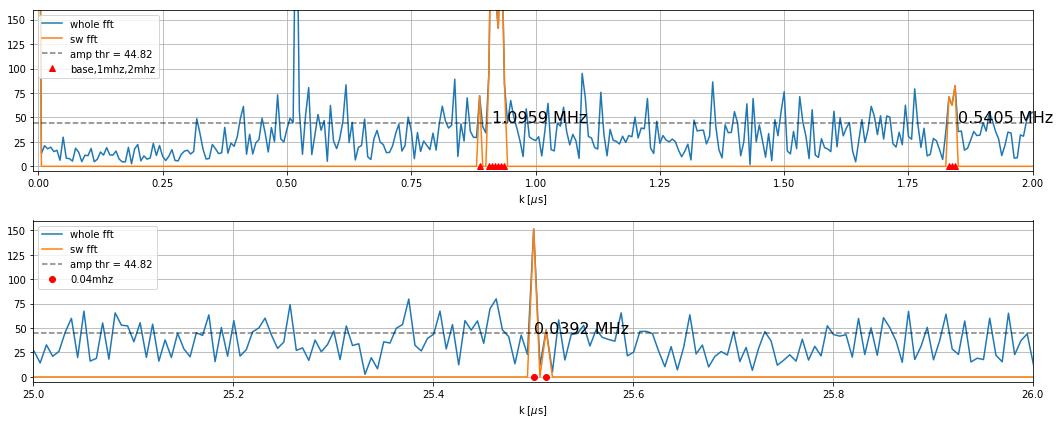

In [45]:
sw = fit_ripple(data_rep,freq,'rfft', is_rfi_num,not_rfi_num,ori_shape,plot = True,
                   is_on = is_on, **fit_args)

In [47]:
rmsw_data = data - sw

In [49]:
from hifast.utils.misc import smooth1d
from markRFI import std,real_std

0.25772888275199624 0.24744145188019487 0.25218127499200976 1.0415752122113409 1.0191553317999031


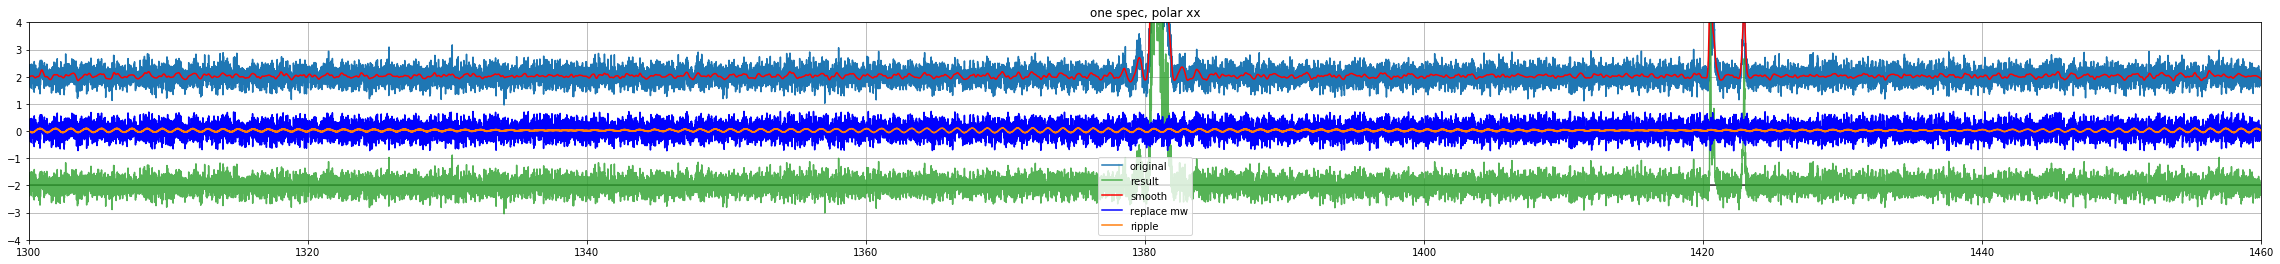

In [52]:
fig = plt.figure(figsize=(40,4))
ax = fig.add_subplot(111)
ax.hlines([0,-2],freq[0],freq[-1],alpha = .8)
ax.plot(freq,data[tn]+2,label='original')
#ax.plot(freq,sw_fit_xx[tn]+2,label='ripple')
ax.plot(freq,rmsw_data[tn] -2,label='result',c='C2',alpha = .8)
ax.plot(freq,smooth1d(data[tn],method='gaussian', sigma=10) +2,'r',label = 'smooth')
ax.plot(freq,data_rep[tn],'b',label='replace mw')
ax.plot(freq,sw[tn],c= 'C1',label='ripple')
ax.set_xlim(freq[0],freq[-1])
ax.set_ylim(-4,4) 
ax.grid();ax.legend();ax.set_title(f'one spec, polar xx')

spec = data[tn]
std_range = [1360,1365]
ori = std(spec,freq,std_range)
real = real_std(spec,freq,10,std_range)
ret = std(rmsw_data[tn],freq,std_range)
print(ori,real,ret,ori/real,ret/real)

# 平均值/中值谱线去基线(cli_baseline_mean)

* --sub_method: mean或median，取平均或中值前后若干条谱线作为基线
* --nspec: 平均谱线条数，默认10条。过少容易损失信号，过多容易驻波变化了。

输出文件名含mean_bld/med_bld

```
python cli_baseline_mean.py $fname --outdir $outdir \
        --sub_method mean --nspec 100 --frange 1330 1360 \
        --plot --ylim -1 .5 --vmin_max -.05 .05 -f --keep_polar --fill_rfi nan || exit 1 
```

In [53]:
sep = h5py.File('/data/inspur_disk01/userdir/jyj/FAST/jingyj/M31_snapshot/data/M31_SnapShot_6_snapshot-M06_W-20210730-specs_T.hdf5','r')
data_sep = get_data(sep,polar='yy')[:][:2000]

In [55]:
sw_mean = fit_ripple(data_sep, method='mean',nspec=10)
rmsw_data_mean = data_sep - sw_mean

  0%|          | 0/2000 [00:00<?, ?it/s]

INFO: Fit baseline ripple with mean method ... [baseline_2]
mean 10


100%|██████████| 2000/2000 [00:01<00:00, 1460.59it/s]


目前有周期RFI，而且平均太多驻波相位会有变化。noise on与off变化明显，所以不应平均太多。太少会失去源的流量。需要注意，由于不同谱线基线不同，还需要使用cli_baseline.py多项式去一次基线。